# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
Berikut adalah penjelasan masing-masing fitur dalam dataset:

| **Fitur**   | **Deskripsi** |
|------------|--------------|
| **age** | Usia pemegang asuransi (primary beneficiary). |
| **sex** | Jenis kelamin pemegang asuransi (**female** atau **male**). |
| **bmi** | **Body Mass Index (BMI)**, menunjukkan proporsi berat badan terhadap tinggi badan. Nilai ideal antara **18.5 - 24.9**. |
| **children** | Jumlah anak yang tercakup dalam asuransi kesehatan (jumlah tanggungan). |
| **smoker** | Status merokok individu (**yes** atau **no**). |
| **region** | Wilayah tempat tinggal individu di AS (**northeast, southeast, southwest, northwest**). |
| **charges** | **Biaya medis** yang dikenakan kepada individu oleh asuransi kesehatan. |

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Sklearn Modules
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
data = 'https://raw.githubusercontent.com/silviaazahro/Prediksi-Biaya-Medis/refs/heads/main/insurance.csv'
df = pd.read_csv(data)
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
#Type your code here
# Menampilkan informasi tentang dataset
df.info()
print("Daftar Kolom:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
Daftar Kolom: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


In [5]:
for col in df.columns:
    print("\n====================================")
    print("Fitur:", col)
    print("Tipe Data:", df[col].dtype)
    print("Jumlah Variable:", df[col].nunique())
    print("Contoh Nilai:", df[col].unique()[:5])


Fitur: age
Tipe Data: int64
Jumlah Variable: 47
Contoh Nilai: [19 18 28 33 32]

Fitur: sex
Tipe Data: object
Jumlah Variable: 2
Contoh Nilai: ['female' 'male']

Fitur: bmi
Tipe Data: float64
Jumlah Variable: 548
Contoh Nilai: [27.9   33.77  33.    22.705 28.88 ]

Fitur: children
Tipe Data: int64
Jumlah Variable: 6
Contoh Nilai: [0 1 3 2 5]

Fitur: smoker
Tipe Data: object
Jumlah Variable: 2
Contoh Nilai: ['yes' 'no']

Fitur: region
Tipe Data: object
Jumlah Variable: 4
Contoh Nilai: ['southwest' 'southeast' 'northwest' 'northeast']

Fitur: charges
Tipe Data: float64
Jumlah Variable: 1337
Contoh Nilai: [16884.924    1725.5523   4449.462   21984.47061  3866.8552 ]


In [6]:
#melihat apakah ada missing value
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


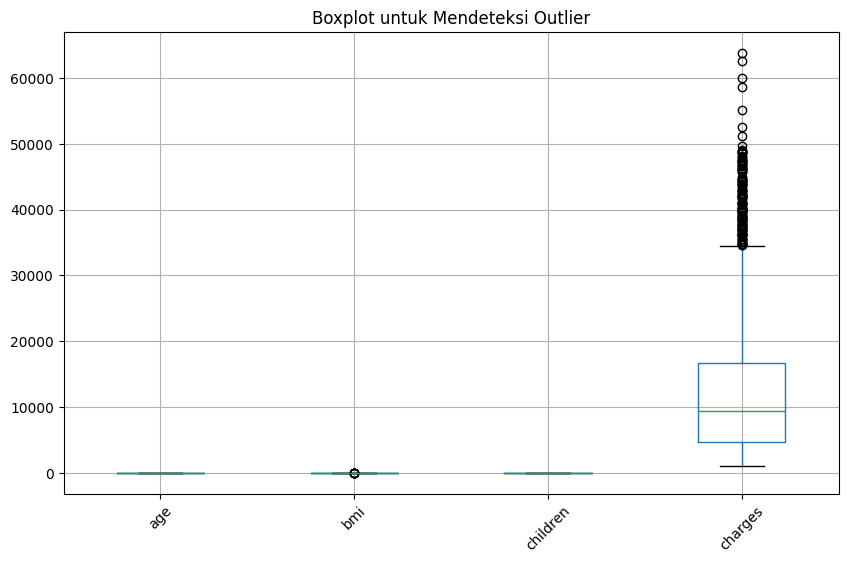

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df_numeric = df.select_dtypes(include=['number'])
df_numeric.boxplot(rot=45)
plt.title("Boxplot untuk Mendeteksi Outlier")
plt.show()

In [8]:
# fd = pd.DataFrame(df)

# Menampilkan semua baris yang duplikat
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

     age   sex    bmi  children smoker     region    charges
195   19  male  30.59         0     no  northwest  1639.5631
581   19  male  30.59         0     no  northwest  1639.5631


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1337 non-null   float64
 1   sex          1337 non-null   object 
 2   bmi          1337 non-null   float64
 3   children     1337 non-null   float64
 4   smoker       1337 non-null   object 
 5   region       1337 non-null   object 
 6   charges      1337 non-null   float64
 7   charges_log  1337 non-null   float64
dtypes: float64(5), object(3)
memory usage: 94.0+ KB

Summary Statistics:
               age          bmi     children      charges  charges_log
count  1337.000000  1337.000000  1337.000000  1337.000000  1337.000000
mean      0.461351     0.395573     0.219147     0.194055     0.514047
std       0.305312     0.164123     0.241114     0.193306     0.227397
min       0.000000     0.000000     0.000000     0.000000     0.000000
25%       0.195652     0.277912     

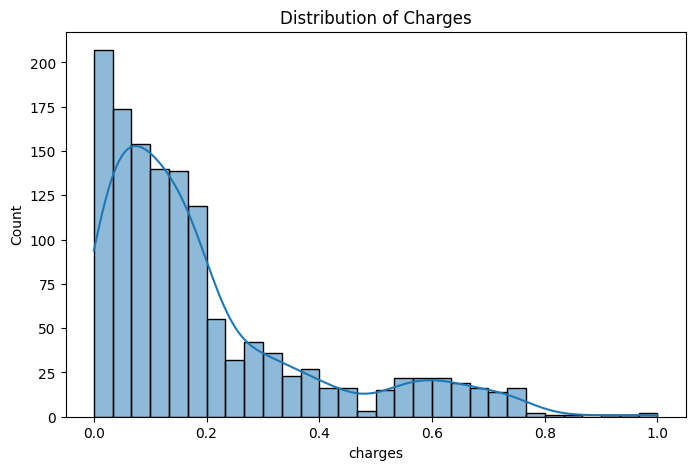

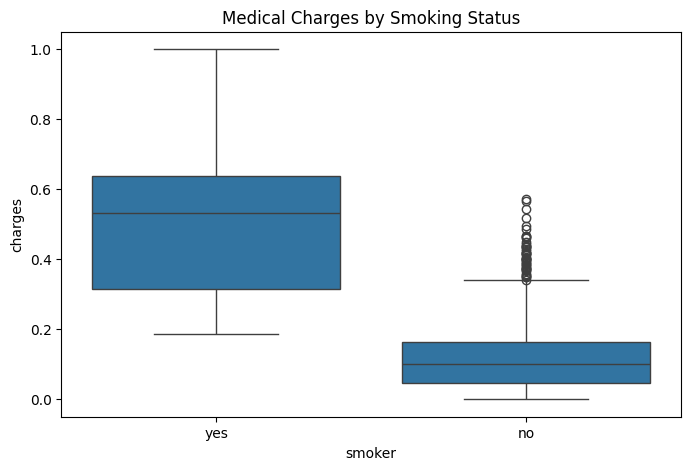

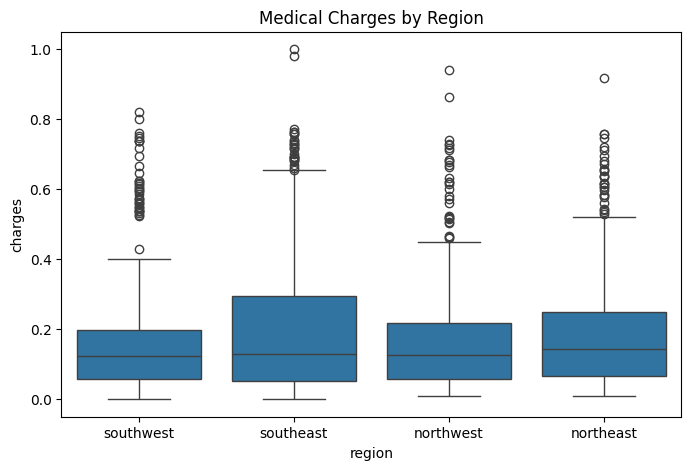

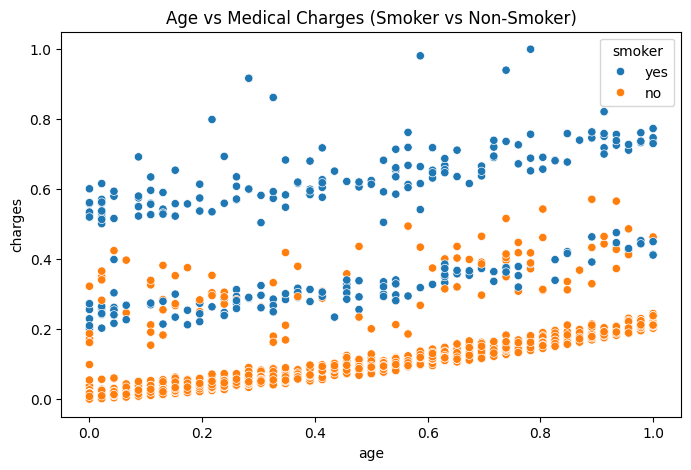

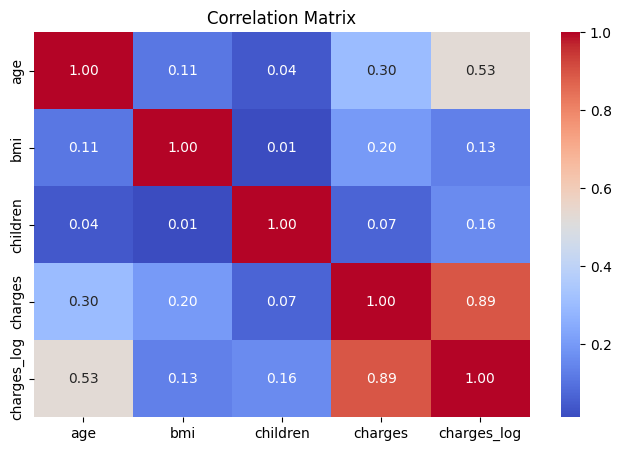

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Basic Info
print("Dataset Info:")
df.info()

# Statistik Ringkasan
print("\nSummary Statistics:")
print(df.describe())

# Cek Value Unik di Kolom
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())

# Visualisasi
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title("Distribution of Charges")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Medical Charges by Smoking Status")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='region', y='charges', data=df)
plt.title("Medical Charges by Region")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title("Age vs Medical Charges (Smoker vs Non-Smoker)")
plt.show()

# Calculate correlation only for numerical features
plt.figure(figsize=(8,5))
numerical_df = df.select_dtypes(include=['number'])  # Select only numerical columns
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [9]:
# Mengidentifikasi Mean-Median-Modus
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
# Membersihkan data duplicates
df = df.drop_duplicates()
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [11]:
# Mengecek Missing Value
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [12]:
import numpy as np

# Menghitung Q1, Q3, dan IQR
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan batas atas
batas_bawah = Q1 - (1.5 * IQR)
batas_atas = Q3 + (1.5 * IQR)

# Menemukan outlier
outliers = df[(df['charges'] < batas_bawah) | (df['charges'] > batas_atas)]
print(f"Jumlah Outlier: {outliers.shape[0]}")


Jumlah Outlier: 139


Text(0.5, 1.0, 'Distribusi Awal Kolom Charges')

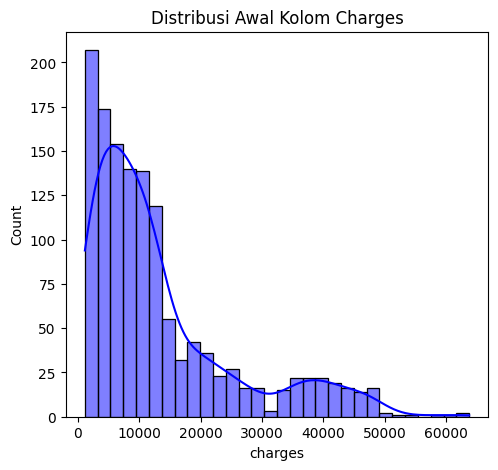

In [13]:
# Cek distribusi awal
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], bins=30, kde=True, color='blue')
plt.title("Distribusi Awal Kolom Charges")

In [14]:
# Log Transformation (gunakan log1p untuk menghindari log(0))
df['charges_log'] = np.log1p(df['charges'])

/tmp/ipykernel_1435/3810059375.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['charges_log'] = np.log1p(df['charges'])


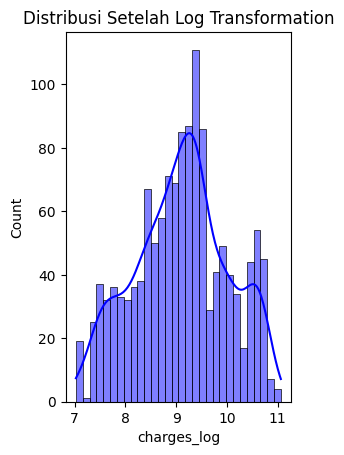

In [15]:
plt.subplot(1, 2, 2)
sns.histplot(df['charges_log'], bins=30, kde=True, color='blue')
plt.title("Distribusi Setelah Log Transformation")

plt.show()

In [16]:
from sklearn.preprocessing import MinMaxScaler
# Mendefinisikan variabel numerical_cols
numerical_cols = df.select_dtypes(include=['number']).columns

# Normalisasi Data
scaler = MinMaxScaler(feature_range=(0, 1))
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Menampilkan 5 data pertama setelah normalisasi
print("\nData setelah normalisasi:")
print(df.head())


Data setelah normalisasi:
        age     sex       bmi  children smoker     region   charges  \
0  0.021739  female  0.321227       0.0    yes  southwest  0.251611   
1  0.000000    male  0.479150       0.2     no  southeast  0.009636   
2  0.217391    male  0.458434       0.6     no  southeast  0.053115   
3  0.326087    male  0.181464       0.0     no  northwest  0.333010   
4  0.304348    male  0.347592       0.0     no  northwest  0.043816   

   charges_log  
0     0.671035  
1     0.106509  
2     0.340920  
3     0.736367  
4     0.306185  


/tmp/ipykernel_1435/2521038758.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


In [18]:
from sklearn.preprocessing import LabelEncoder

# Kolom-kolom yang ingin di-encode
kolom_kategorikal = ['sex', 'smoker', 'region']

# Buat tempat menyimpan encoder untuk masing-masing kolom
label_encoders = {}

# Lakukan encoding untuk tiap kolom
for kolom in kolom_kategorikal:
    le = LabelEncoder()
    df[kolom] = le.fit_transform(df[kolom])  # Ubah teks jadi angka
    label_encoders[kolom] = le  # Simpan encoder-nya

# Buat salinan dataframe hasil encoding
df_encoded = df.copy()

/tmp/ipykernel_1435/3084703316.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[kolom] = le.fit_transform(df[kolom])  # Ubah teks jadi angka
/tmp/ipykernel_1435/3084703316.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[kolom] = le.fit_transform(df[kolom])  # Ubah teks jadi angka
/tmp/ipykernel_1435/3084703316.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [19]:
#Menampilkan hasil transformasi
df_encoded.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,0.021739,0,0.321227,0.0,1,3,0.251611,0.671035
1,0.000000,1,0.479150,0.2,0,2,0.009636,0.106509
2,0.217391,1,0.458434,0.6,0,2,0.053115,0.340920
3,0.326087,1,0.181464,0.0,0,1,0.333010,0.736367
4,0.304348,1,0.347592,0.0,0,1,0.043816,0.306185


In [20]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Membuat kategori charger dengan binning
bins = [df["charges"].min(),
        df["charges"].quantile(0.25),   # Q1
        df["charges"].quantile(0.50),   # Median (Q2)
        df["charges"].quantile(0.75),   # Q3
        df["charges"].max() + 1]

labels = ["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]

# Proses binning menggunakan pd.cut()
df_encoded['charges_kategori'] = pd.cut(
    df_encoded['charges'],
    bins=bins,
    labels=labels,
    right=False  # Interval [awal, akhir)
)

# Encoding kategori charger
label_encoder_kategori = LabelEncoder()
df_encoded['charges_kategori'] = label_encoder_kategori.fit_transform(
    df_encoded['charges_kategori']
)

# Menampilkan hasil akhir
print("\nData setelah binning charges:")
print(df_encoded)


Data setelah binning charges:
           age  sex       bmi  children  smoker  region   charges  \
0     0.021739    0  0.321227       0.0       1       3  0.251611   
1     0.000000    1  0.479150       0.2       0       2  0.009636   
2     0.217391    1  0.458434       0.6       0       2  0.053115   
3     0.326087    1  0.181464       0.0       0       1  0.333010   
4     0.304348    1  0.347592       0.0       0       1  0.043816   
...        ...  ...       ...       ...     ...     ...       ...   
1333  0.695652    1  0.403820       0.6       0       1  0.151299   
1334  0.000000    0  0.429379       0.0       0       0  0.017305   
1335  0.000000    0  0.562012       0.0       0       2  0.008108   
1336  0.065217    0  0.264730       0.0       0       3  0.014144   
1337  0.934783    0  0.352704       0.0       1       1  0.447249   

      charges_log  charges_kategori  
0        0.671035                 1  
1        0.106509                 0  
2        0.340920         

In [21]:
# Memilih kolom untuk dataset final
# Kita akan menghapus 'charges_log' dan 'charges_kategori' jika target utama kita adalah 'charges' hasil normalisasi.
# Atau sesuaikan berdasarkan kebutuhan model Anda.
df_final = df_encoded.drop(columns=['charges_log', 'charges_kategori'])

print("Dataset Final (5 baris pertama):")
display(df_final.head())

# Menyimpan dataset hasil preprocessing ke file CSV
df_final.to_csv('insurance_preprocessed.csv', index=False)
print("\nDataset berhasil disimpan dengan nama: insurance_preprocessed.csv")

Dataset Final (5 baris pertama):


,age,sex,bmi,children,smoker,region,charges
0,0.021739,0,0.321227,0.0,1,3,0.251611
1,0.000000,1,0.479150,0.2,0,2,0.009636
2,0.217391,1,0.458434,0.6,0,2,0.053115
3,0.326087,1,0.181464,0.0,0,1,0.333010
4,0.304348,1,0.347592,0.0,0,1,0.043816



Dataset berhasil disimpan dengan nama: insurance_preprocessed.csv
